In [5]:
import subprocess

# Step 1: Create the PHREEQC input file
input_file_content = """

TITLE Example 5.--Add oxygen, equilibrate with pyrite, calcite, and goethite.
SOLUTION 1  PURE WATER
        pH      7.0
        temp    25.0
EQUILIBRIUM_PHASES 1
        Pyrite          0.0
        Goethite        0.0
        Calcite         0.0
        CO2(g)         -3.5
        Gypsum          0.0     0.0
REACTION 1
        O2      1.0
        NaCl    0.5
        0.0     0.001   0.005   0.01   0.03   0.05
SELECTED_OUTPUT
        -file   ex5_output.txt
        -total  Cl
        -si     Gypsum
        -equilibrium_phases  pyrite goethite calcite CO2(g) gypsum
 END   

"""

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ========================== NO TOCAR ESTA PARTE ================================================
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
input_file_name = "phreeqc_input_file.pqi"
with open(input_file_name, "w") as file:
    file.write(input_file_content)
print(f"PHREEQC input file '{input_file_name}' created successfully.")

# Step 2: Run PHREEQC using subprocess
output_file_name = "phreeqc_output.txt"
database_file = "/opt/shared/PHREEQC_code/phreeqc-3.8.6-17100/database/phreeqc.dat"  # Update the path if necessary
phreeqc_executable = "/opt/shared/PHREEQC_code/phreeqc-3.8.6-17100/src/phreeqc"  # Use "phreeqc.exe" on Windows, or the full path to the executable

# Run PHREEQC
try:
    subprocess.run([phreeqc_executable, input_file_name, output_file_name, database_file], check=True)
    print(f"PHREEQC run completed. Output saved in '{output_file_name}'.")
except subprocess.CalledProcessError as e:
    print(f"PHREEQC execution failed: {e}")
    
# Display the contents of the output file, ignoring problematic characters
try:
    with open(output_file_name, "r", encoding="utf-8", errors="ignore") as output_file:
        output_content = output_file.read()
    print("PHREEQC Output:\n")
    print(output_content)
except FileNotFoundError:
    print(f"Output file '{output_file_name}' not found.")    

#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ================================================================================================
#+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

PHREEQC input file 'phreeqc_input_file.pqi' created successfully.
PHREEQC run completed. Output saved in 'phreeqc_output.txt'.
PHREEQC Output:

   Input file: phreeqc_input_file.pqi
  Output file: phreeqc_output.txt
Database file: /opt/shared/PHREEQC_code/phreeqc-3.8.6-17100/database/phreeqc.dat

------------------
Reading data base.
------------------

	SOLUTION_MASTER_SPECIES
	SOLUTION_SPECIES
	PHASES
	GAS_BINARY_PARAMETERS
	EXCHANGE_MASTER_SPECIES
	EXCHANGE_SPECIES
	SURFACE_MASTER_SPECIES
	SURFACE_SPECIES
	MEAN_GAMMAS
	RATES
	END
------------------------------------
Reading input data for simulation 1.
------------------------------------

	TITLE Example 5.--Add oxygen, equilibrate with pyrite, calcite, and goethite.
	SOLUTION 1  PURE WATER
	        pH      7.0
	        temp    25.0
	EQUILIBRIUM_PHASES 1
	        Pyrite          0.0
	        Goethite        0.0
	        Calcite         0.0
	        CO2(g)         -3.5
	        Gypsum          0.0     0.0
	REACTION 1
	        O2     

Input file: phreeqc_input_file.pqi

Output file: phreeqc_output.txt

Database file: /opt/shared/PHREEQC_code/phreeqc-3.8.6-17100/database/phreeqc.dat

              █▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀▀█
              ║                                            ║
              ║             * PHREEQC-3.8.6 *              ║
              ║                                            ║
              ║      A hydrogeochemical transport model    ║
              ║                                            ║
              ║                    by                      ║
              ║       D.L. Parkhurst and C.A.J. Appelo     ║
              ║                                            ║
              ║              January  7, 2025              ║
              █▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄█


Initializing...                                                                 

End of Run after 0.010499 Seconds.


/tmp/ipykernel_27580/2810486655.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, skipinitialspace=True)


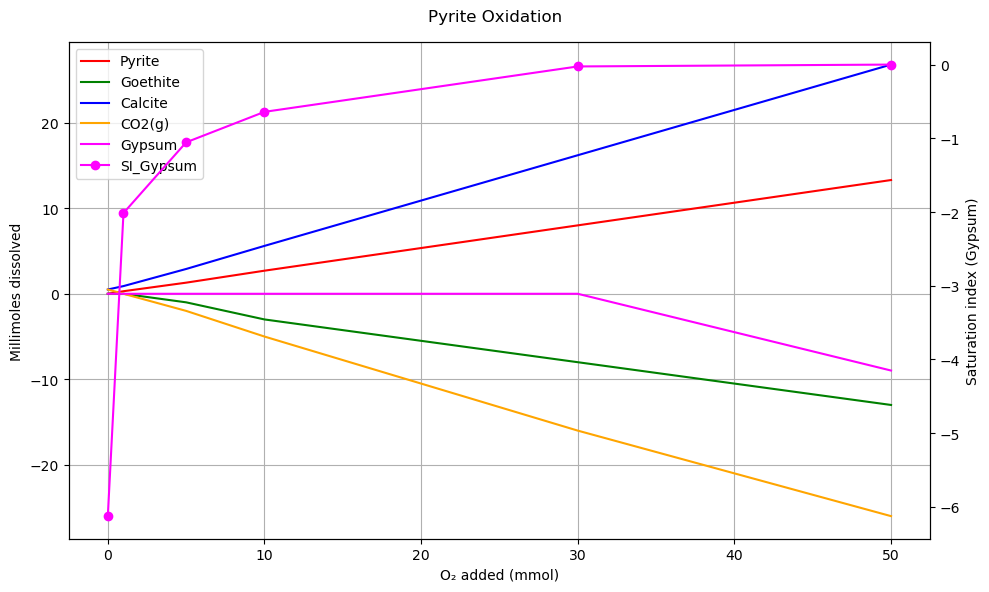

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
file_path = 'ex5_output.txt'  # Adjust as needed
df = pd.read_csv(file_path, delim_whitespace=True, skipinitialspace=True)

# Remove the first (i_soln) row
df = df[df['state'] != 'i_soln'].copy()

# Compute O2 added (in millimoles)
# Each reaction step adds a certain amount of O2; we assume equal increments
o2_added = [0.0, 1.0, 5.0, 10.0, 30.0, 50.0]  # or calculate from reaction definition
df['O2_added'] = o2_added[:len(df)]

# Calculate amount dissolved (10 mmol initial - current equilibrium amount)
initial = 10.0
df['Pyrite_dissolved'] = 1e3 * (initial - df['pyrite'])
df['Goethite_dissolved'] = 1e3 * (initial - df['goethite'])
df['Calcite_dissolved'] = 1e3 * (initial - df['calcite'])
df['CO2_dissolved'] = 1e3 * (initial - df['CO2(g)'])
df['Gypsum_dissolved'] = -1e3 * df['gypsum']  # dissolution is -EQUI in phreeqc

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Left y-axis: mmol dissolved
ax1.plot(df['O2_added'], df['Pyrite_dissolved'], 'r-', label='Pyrite')
ax1.plot(df['O2_added'], df['Goethite_dissolved'], 'g-', label='Goethite')
ax1.plot(df['O2_added'], df['Calcite_dissolved'], 'b-', label='Calcite')
ax1.plot(df['O2_added'], df['CO2_dissolved'], color='orange', label='CO2(g)')
ax1.plot(df['O2_added'], df['Gypsum_dissolved'], color='magenta', label='Gypsum')
ax1.set_xlabel("O₂ added (mmol)")
ax1.set_ylabel("Millimoles dissolved")
ax1.grid(True)

# Right y-axis: SI_Gypsum
ax2 = ax1.twinx()
ax2.plot(df['O2_added'], df['si_Gypsum'], 'o-', color='magenta', label='SI_Gypsum')
ax2.set_ylabel("Saturation index (Gypsum)")

# Title and legend
fig.suptitle("Pyrite Oxidation")
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.tight_layout()
plt.show()
